## Permutation Feature Importance — FULL MASTER CODE
Covers:

✅ Basic bar plot

✅ Horizontal bar plot

✅ Error bars (stability)

✅ Boxplot (distribution)

✅ Cumulative importance curve

✅ Comparison with model-based importance

✅ Heatmap-style ranking

✅ Bootstrap stability view

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")
np.random.seed(42)


In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


### Train Model

In [3]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Compute Permutation Importance

In [4]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "mean_importance": perm.importances_mean,
    "std_importance": perm.importances_std
}).sort_values("mean_importance", ascending=False)


### Standard Vertical Bar Plot

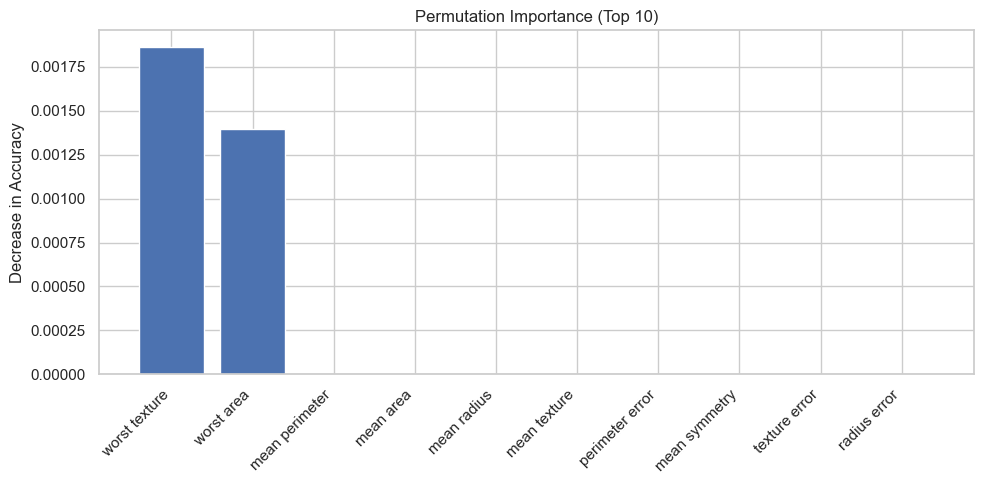

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(
    perm_df.head(10)["feature"],
    perm_df.head(10)["mean_importance"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Decrease in Accuracy")
plt.title("Permutation Importance (Top 10)")
plt.tight_layout()
plt.show()


### Horizontal Bar Plot (Cleanest View)

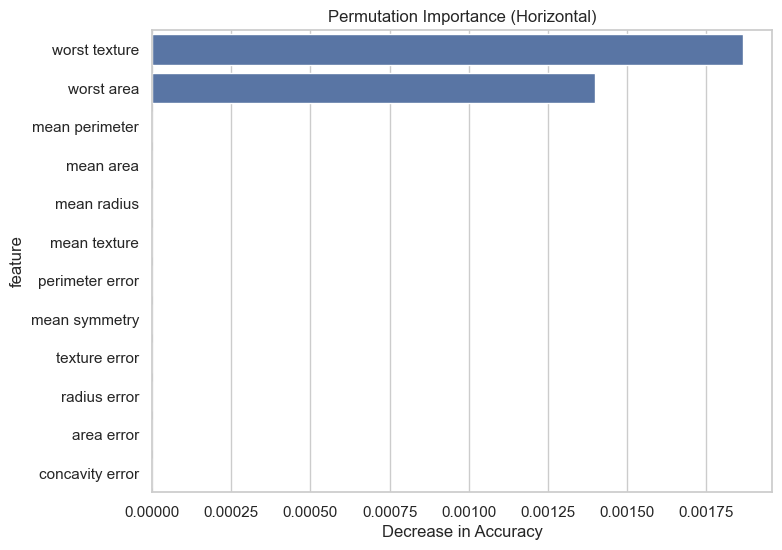

In [6]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=perm_df.head(12),
    x="mean_importance",
    y="feature"
)
plt.xlabel("Decrease in Accuracy")
plt.title("Permutation Importance (Horizontal)")
plt.show()


### Importance with Error Bars (Stability)

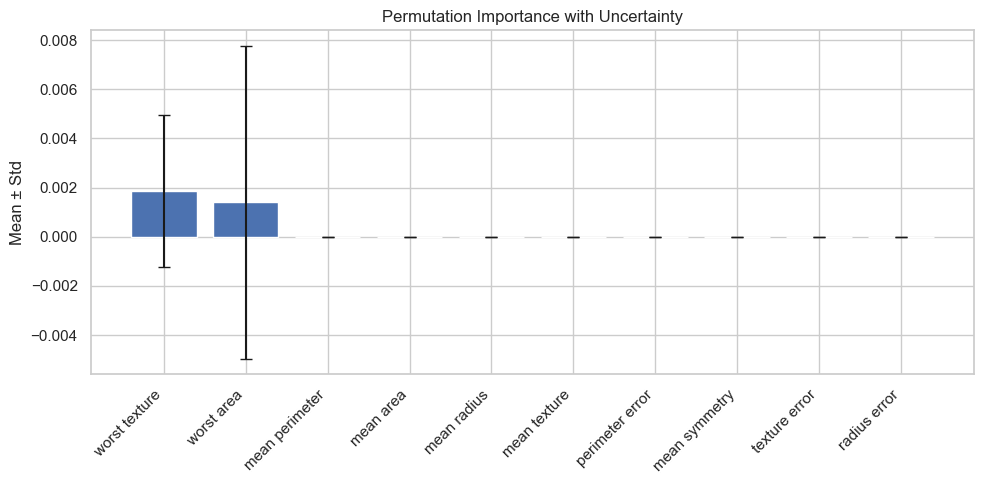

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(
    perm_df.head(10)["feature"],
    perm_df.head(10)["mean_importance"],
    yerr=perm_df.head(10)["std_importance"],
    capsize=4
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean ± Std")
plt.title("Permutation Importance with Uncertainty")
plt.tight_layout()
plt.show()


### Boxplot (Distribution Across Permutations)

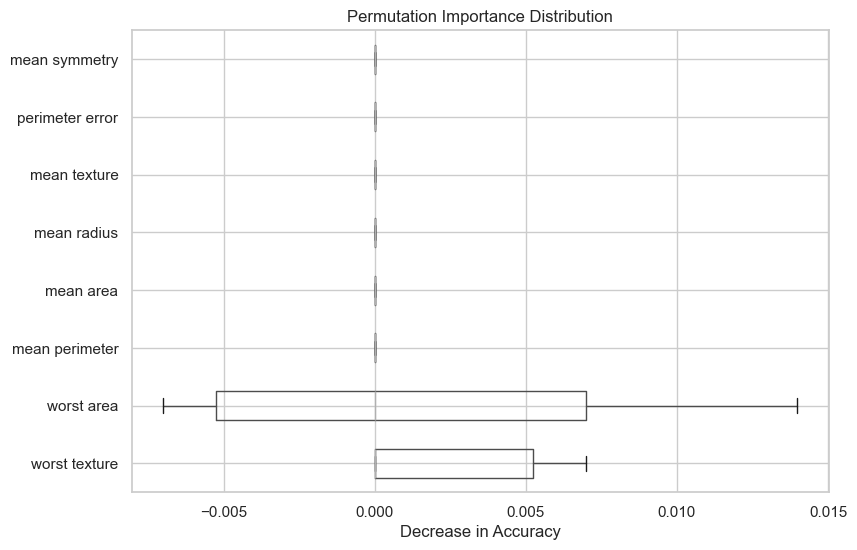

In [8]:
top_features = perm_df.head(8)["feature"]

box_data = pd.DataFrame(
    perm.importances.T,
    columns=X.columns
)[top_features]

plt.figure(figsize=(9, 6))
box_data.boxplot(vert=False)
plt.title("Permutation Importance Distribution")
plt.xlabel("Decrease in Accuracy")
plt.show()


### Cumulative Importance Curve

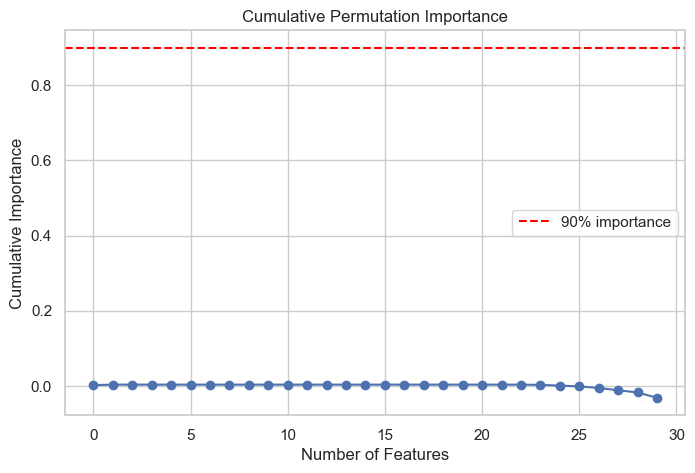

In [9]:
sorted_vals = perm_df["mean_importance"].values
cumulative = np.cumsum(sorted_vals)

plt.figure(figsize=(8, 5))
plt.plot(cumulative, marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="90% importance")
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Permutation Importance")
plt.legend()
plt.show()


### Comparison with Model-Based Importance

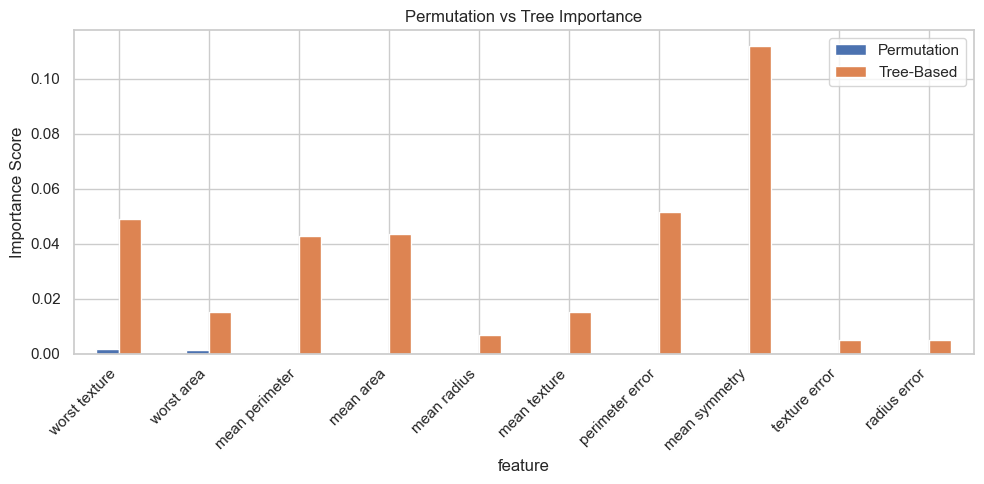

In [10]:
compare_df = pd.DataFrame({
    "Permutation": perm_df.set_index("feature")["mean_importance"],
    "Tree-Based": model.feature_importances_
}).dropna()

compare_df = compare_df.sort_values("Permutation", ascending=False).head(10)

compare_df.plot(kind="bar", figsize=(10, 5))
plt.title("Permutation vs Tree Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Heatmap-Style Ranking

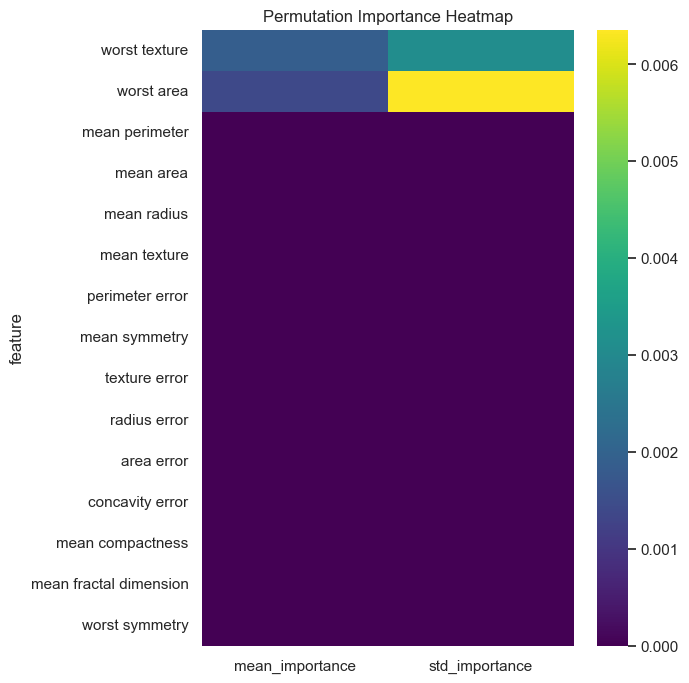

In [11]:
plt.figure(figsize=(6, 8))
sns.heatmap(
    perm_df.head(15).set_index("feature"),
    cmap="viridis",
    annot=False
)
plt.title("Permutation Importance Heatmap")
plt.show()


### Bootstrap Stability (Advanced)

In [ ]:
boot_scores = []

for i in range(25):
    Xb, _, yb, _ = train_test_split(
        X_train, y_train, test_size=0.3
    )
    model.fit(Xb, yb)

    r = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, random_state=i
    )
    boot_scores.append(r.importances_mean)

boot_df = pd.DataFrame(boot_scores, columns=X.columns)

plt.figure(figsize=(9, 6))
boot_df[perm_df.head(8)["feature"]].boxplot(vert=False)
plt.title("Bootstrap Permutation Importance Stability")
plt.xlabel("Importance")
plt.show()
